In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### 1. UNDERSTANDING THE DATASET

In [8]:
df=pd.read_csv("C:/customer-churn-project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
print(f"The dataset has \nrows: {df.shape[0]}\ncolumns: {df.shape[1]}")

The dataset has 
rows: 7043
columns: 21


In [17]:
print(f"The dataset contains columns :\n{df.columns}")

The dataset contains columns :
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.HANDLING NULL VALUES AND WRONG DATATYPES

In [19]:
#check for any null values 
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
#Totalcharges col has wrong datatype changing it to float
any_obj=pd.to_numeric(df["TotalCharges"],errors='coerce').isna()
df.loc[any_obj,'TotalCharges'].value_counts()

TotalCharges
    11
Name: count, dtype: int64

In the TotalCharges col we have blank spaces which are considering as string "  "  
so we need to clean them

In [26]:
#Replacing the spaces with NaN,then converting the col to the numeric col
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [28]:
df['TotalCharges'].dtype

dtype('float64')

In [30]:
#checking null values
df["TotalCharges"].isnull().sum()

11

In [31]:
#Check the Mean,median of the col to fill the null values with correct value
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

Observation:    
            Mean is not suited for this because the data distribution is skewed  
            Filling the null values with median is best option
        

In [33]:
#Filling null value with median
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)
df['TotalCharges'].isna().sum()

0

In [43]:
#check any duplicate values
df.duplicated().sum()

0

In [34]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [44]:
#separting categorical cols and numeric cols to separate operations on them 
categorical_cols=['customerID','gender','Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
numeric_cols=['SeniorCitizen','tenure', 'MonthlyCharges', 'TotalCharges']


**Churn is the Target col**

### 3.Visualisation Analysis

In [50]:
#First check the target col
df.Churn.value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

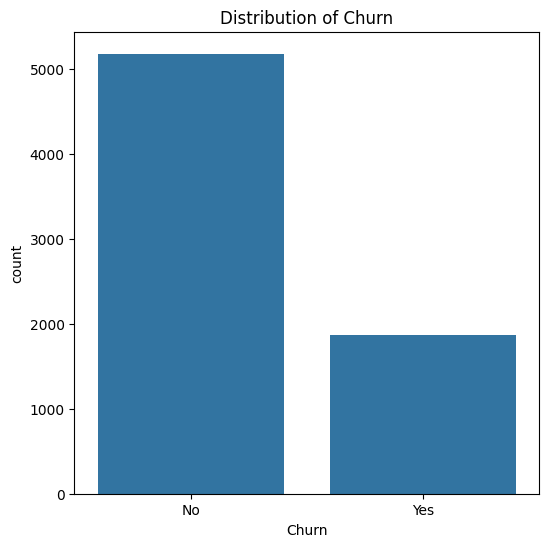

In [52]:
plt.figure(figsize=(6,6))
sns.countplot(x='Churn',data=df)
plt.title("Distribution of Churn")
plt.show()


OBSERVATION  :  
The target variable is moderately imbalanced, with non-churn customers dominating the dataset. This means accuracy alone may be misleading, so recall, precision, and F1-score must be considered during model evaluation.


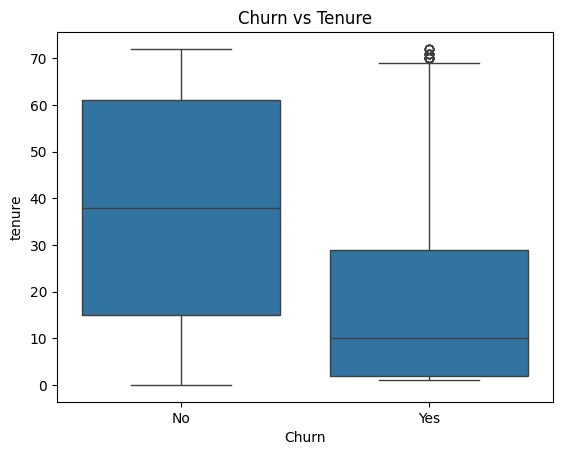

In [56]:
#tenure vs churn
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title("Churn vs Tenure")
plt.show()

Observation :  
Customers who churn tend to have lower tenure, indicating that newer customers are more likely to leave. This suggests that early onboarding and first-month retention strategies are important.


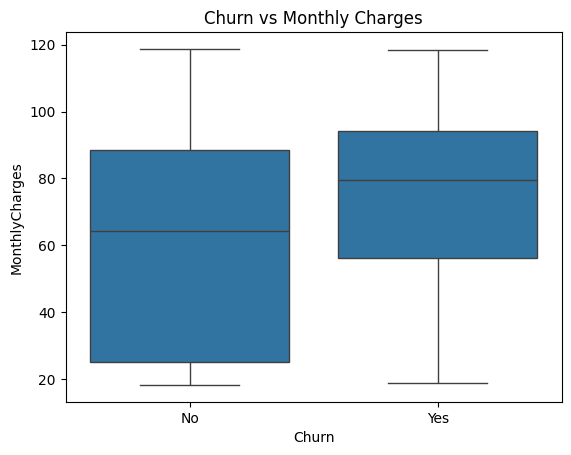

In [58]:
#Check for Monthly charges associated with churn
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

Observation :  
Customers with higher monthly charges appear more associated with churn. However, monthly charges alone may not be the direct cause, since other factors such as contract type, tenure, and service quality may also influence churn.


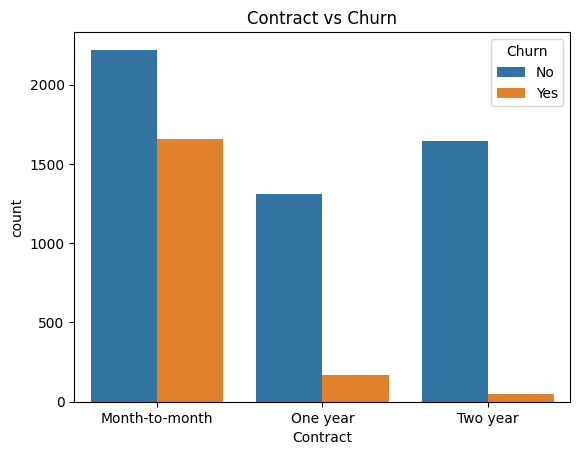

In [62]:
#Checking Wether the contract is asscioated with the churn
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Contract vs Churn")
plt.show()

In [64]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Observation:  
Customers with month-to-month contracts show significantly higher churn compared to one-year and two-year contract customers. This suggests that long-term contracts improve retention and reduce churn risk.


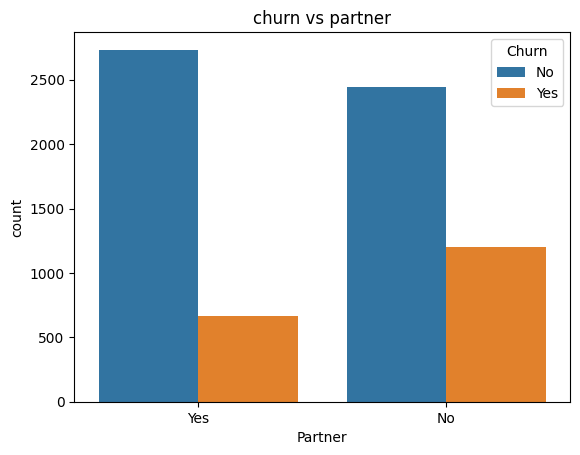

In [66]:
sns.countplot(x='Partner',hue='Churn',data=df)
plt.title('churn vs partner')
plt.show()

Observation:  
Customers with partners appear less likely to churn compared to customers without partners, suggesting more stable retention behavior.


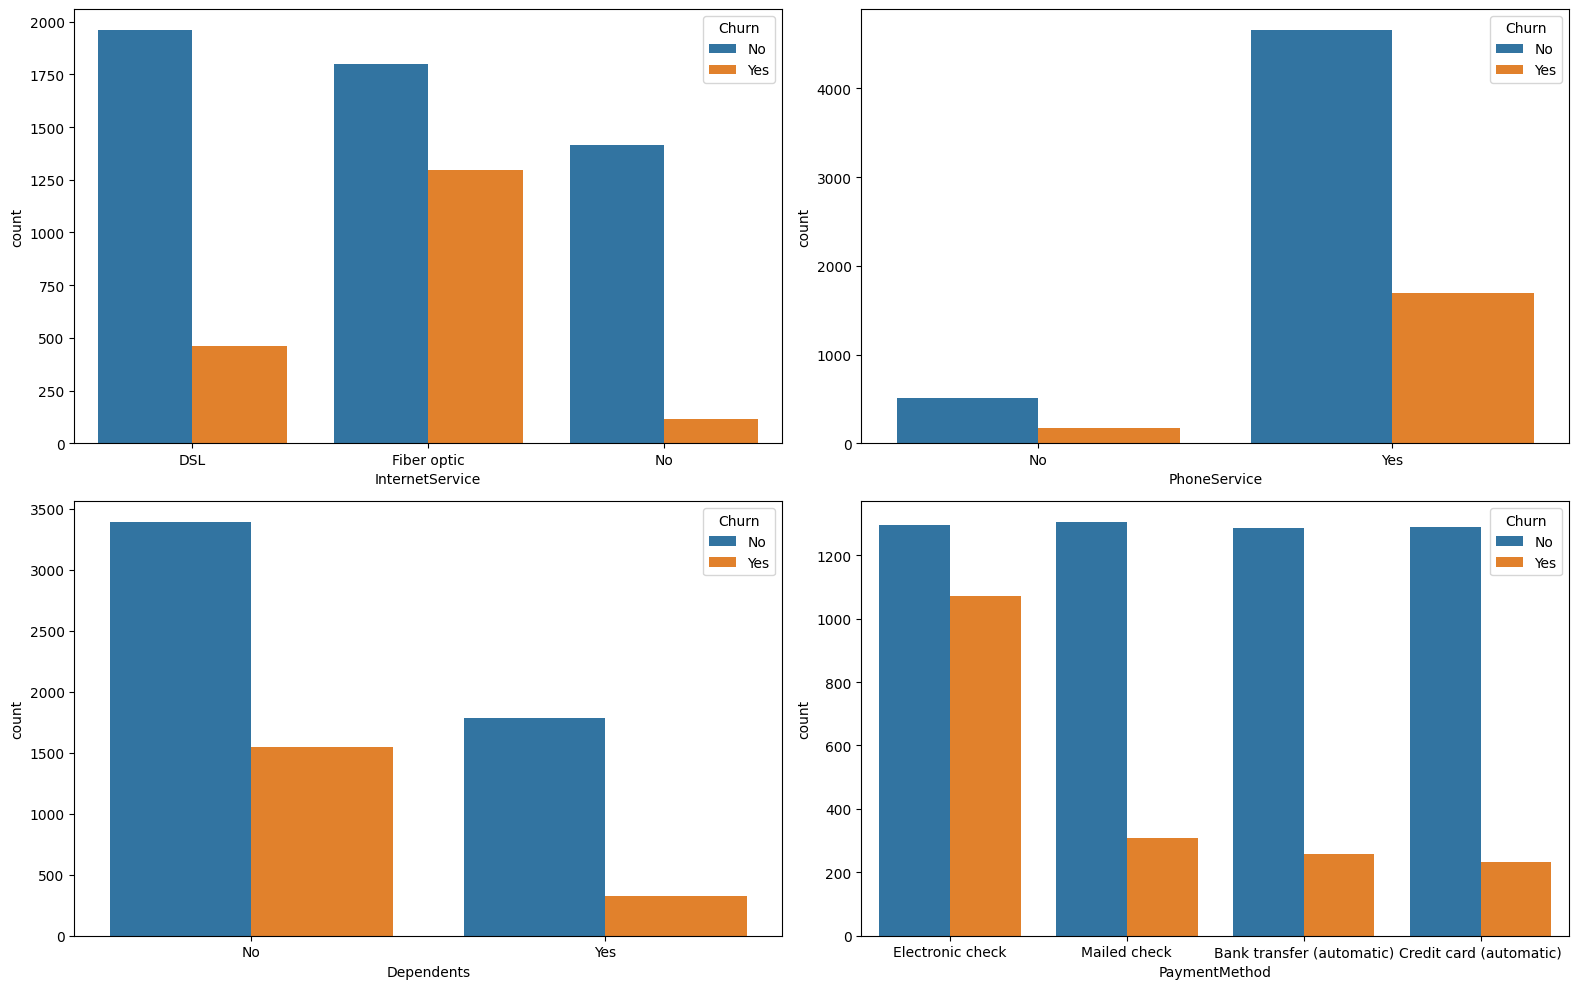

In [77]:
fig,axes=plt.subplots(2,2 ,figsize=(16,10))
sns.countplot(x='InternetService',hue='Churn',data=df,ax=axes[0,0])
sns.countplot(x='PhoneService',hue='Churn',data=df,ax=axes[0,1])
sns.countplot(x='Dependents',hue='Churn',data=df,ax=axes[1,0])
sns.countplot(x='PaymentMethod',hue='Churn',data=df,ax=axes[1,1])
plt.tight_layout()
plt.show()

**Internet Service**

Customers using fiber optic internet show the highest churn compared to DSL and customers without internet service. This suggests fiber optic users may experience pricing concerns, service quality issues, or higher expectations that increase churn risk.

**Phone Service**

Phone service does not show a strong visible churn difference. Customers with and without phone service mostly remain in the non-churn category, suggesting phone service alone may not strongly influence customer churn.

**Dependents**

Customers without dependents show noticeably higher churn compared to customers with dependents. This suggests that customers with family responsibilities may have more stable long-term retention behavior.

**Payment Method**

Customers using electronic check show the highest churn, while customers using automatic payment methods such as bank transfer and credit card show lower churn. This indicates that automated billing may improve customer retention and payment stability.


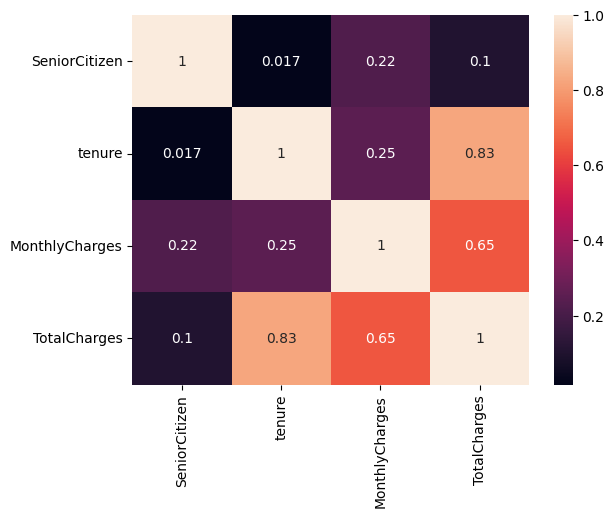

In [79]:
sns.heatmap(df[numeric_cols].corr(),annot=True)
plt.show()

**Correlation Analysis of Numeric Features**

The strongest positive correlation is between **tenure and TotalCharges (0.83)**, indicating that customers who stay longer naturally accumulate higher total billing over time.

**MonthlyCharges and TotalCharges (0.65)** also show moderate positive correlation, meaning customers paying higher monthly fees tend to accumulate larger total charges.

**SeniorCitizen shows very weak correlation with other numeric features**, suggesting age category does not strongly influence billing-related numerical behavior.


### 4.PREPROCESSING

In [81]:
#Removing CustomerId because it is uncessary col for modeling
df.drop('customerID',axis=1,inplace=True)